In [13]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Goal of cell is to define variables

# --- HARDWARE CONSTANTS (Placeholders based on Sensirion flow ranges) ---
D_reactor = 0.003      # Reactor Diameter (Meters) -> 3mm column
V_reactor = 50e-6      # Reactor Volume (50 microliters converted to Liters)
dp = 100e-6            # Bead Diameter (100 microns converted to meters)
epsilon = 0.4          # Bed Porosity (Typical for packed CPG beads)
rho_f = 786.0          # Density of Acetonitrile (kg/m^3)
mu_f = 0.34e-3         # Viscosity of Acetonitrile (Pa*s)
Cp_f = 2200.0          # Specific Heat Capacity (J/kg*K)

# --- KINETIC PRIORS (Derived from Russell 2007) ---
# Using Saccharin/NMI activated phosphoramidite kinetics
R = 8.314              # Universal Gas Constant (J/mol*K)
Ea = 45000             # Activation Energy (J/mol - estimate for coupling)
A_pre = 1.5e7          # Pre-exponential factor (Adjusted for MVM)
k_ref = 0.5            # Rate constant at T_ref (1/s)
T_ref = 298.15         # Reference Temperature (25°C in Kelvin)
dH_rxn = -50000        # Enthalpy of reaction (Exothermic J/mol)

print("Cell 1: Physical environment defined.")

Cell 1: Physical environment defined.


In [14]:
def calculate_bridges(v_s):
    """
    v_s: superficial velocity (m/s)
    """
    # Goal of cell is to define the "connective tissue" the model relies upon
    
    # 1. Reynolds Number (Meso-scale flow)
    Re = (rho_f * v_s * dp) / mu_f
    
    # 2. Schmidt Number (Ratio of momentum to mass diffusivity)
    # D_ab is molecular diffusivity of phosphoramidite in ACN
    D_ab = 1e-9 
    Sc = mu_f / (rho_f * D_ab)
    
    # 3. Sherwood Number (Nelson & Galloway correlation for low Re)
    # This is the 'Bridge' between bulk flow and bead surface
    Sh = (2 / (1 - epsilon)) + 0.5 * (Re**0.5) * (Sc**(1/3))
    
    # 4. Mass Transfer Coefficient (m/s)
    km = (Sh * D_ab) / dp
    
    return km

print("Cell 2: Connective tissue (Bridges) defined.")

Cell 2: Connective tissue (Bridges) defined.


In [15]:
def synthesis_ode(t, x, v_flow):

    # Goal of cell is to define model xdot = f(x,u,p) of printer
    
    # Unpack State Vector: C_bulk, T_reactor; y[0] = C_bulk (mol/L), y[1] = Temp (K)
    Cb, T = x

    # In the future, if aspects of micro or meso scales can not be reduced to variables but remain as equations, we will deal with this 
    # in the Offline Training Phase of the Observer Design using use Hyper-reduction (DEIM). In this case, we will have no choice but to
    # discretize the system
    
    # --- SCALE: MESO (Transport/Flow) ---
    # Calculate Area from initialized Diameter (Meters)
    Area_reactor = np.pi * (D_reactor / 2)**2
    
    # Convert inlet Flow (uL/min) to Volumetric Flow (m^3/s)
    Q_SI = v_flow * 1.666e-11  # conversion factor for uL/min -> m^3/s

    # Calculate interstitial Velocity (m/s)
    # Epsilon (porosity) is included to find the speed of the fluid between the beads.
    v_s = Q_SI / (epsilon * Area_reactor)
    
    # Residence time calculation, Convert Flow to Velocity
    tau = (V_reactor * epsilon) / (Q_SI * 1e-6 / 60) # converting uL/min to L/s
    flow_term = (0.1 - Cb) / tau # 0.1 is the inlet concentration (Russell Prior)
    
    # Mass Transfer Limitation (Connective Tissue)
    km = calculate_bridges(v_s) # Assume v_velocity ~ 0.1 mm/s for MVM; this line calls cell 2

    # --- SCALE: MICRO (Kinetics/Reaction) ---
    # Temperature-dependent rate constant, Intrinstic Kinetics (Arrhenius - Russell 2007)
    k_intrinsic = A_pre * np.exp(-Ea / (R * T))
    
    # Effectiveness Factor (Placeholder for Chain Length Penalty)
    # As chain length increases, eta decreases. For MVM 1, we assume eta=0.9
    eta = 0.9 

    # Sum of Resistances: Condensing Micro-transport and Kinetics
    k_eff = 1 / ((1/km) + (1/k_intrinsic))
    
    # Reaction Rate
    r = eta * k_eff * Cb
    
    # --- COUPLING (Conservation Laws) ---
    dCb_dt = flow_term - r                              # Mass balance
    dT_dt = ((-dH_rxn * r) / (rho_f * Cp_f)) * 1000    # Heat balance
    
    return [dCb_dt, dT_dt]

In [16]:
# Initial Conditions: 0M concentration in reactor, 293K (20C)
x0 = [0.0, 293.0]   # x0 defines the initial state at t = 0, solver handles vectorization of time automatically
                    # T in x0 is not equal to Tref because Tref represents standard laboratory conditions; we assume room temp is 20 C

t_span = (0, 120)   # 2 minutes
flow_rate = 100.0   # uL/min

#Run solver (Radau is best for stiff chemical equations, very similar to ode15s but has differences in time stepping), may allow for
#larger time stepping; cell 3 is called upon here as first argument
sol = solve_ivp(synthesis_ode, t_span, x0, method='Radau', args=(flow_rate,), t_eval=np.linspace(0, 120, 500))

print("Simulation Complete. Proceed to Cell 5 for Visualization.")

Simulation Complete. Proceed to Cell 5 for Visualization.


AttributeError: x

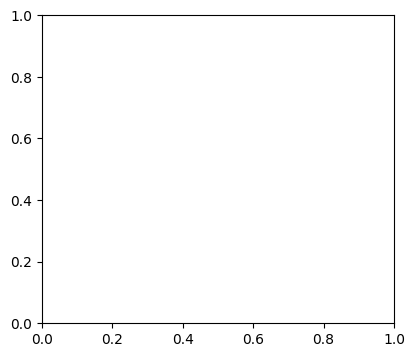

In [17]:
plt.figure(figsize=(10, 4))

# Plot Concentration
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.x[0], color='blue', label='Amidite Conc (M)')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.legend()

# Plot Temperature
plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.x[1], color='red', label='Reactor Temp (K)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.legend()

plt.tight_layout()
plt.show()

# Final Yield Logic
final_yield = (1 - (sol.x[0][-1] / 0.1)) * 100
print(f"Predicted Step Yield: {final_yield:.2f}%")